/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 111MB/s]


Step 50 Style Loss: 5.360362592909951e-06 Content Loss: 4.947010040283203
Step 100 Style Loss: 2.645258746269974e-06 Content Loss: 3.2362008094787598
Step 150 Style Loss: 1.5815371625649277e-06 Content Loss: 2.8645362854003906
Step 200 Style Loss: 1.122799744734948e-06 Content Loss: 2.6891870498657227
Step 250 Style Loss: 9.480918379267678e-07 Content Loss: 2.5704445838928223
Step 300 Style Loss: 8.048606900956656e-07 Content Loss: 2.5128185749053955


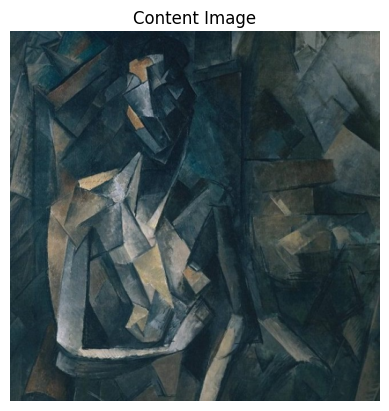

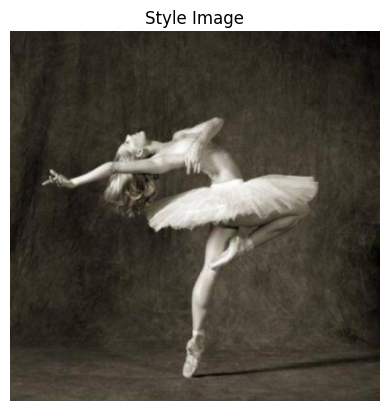

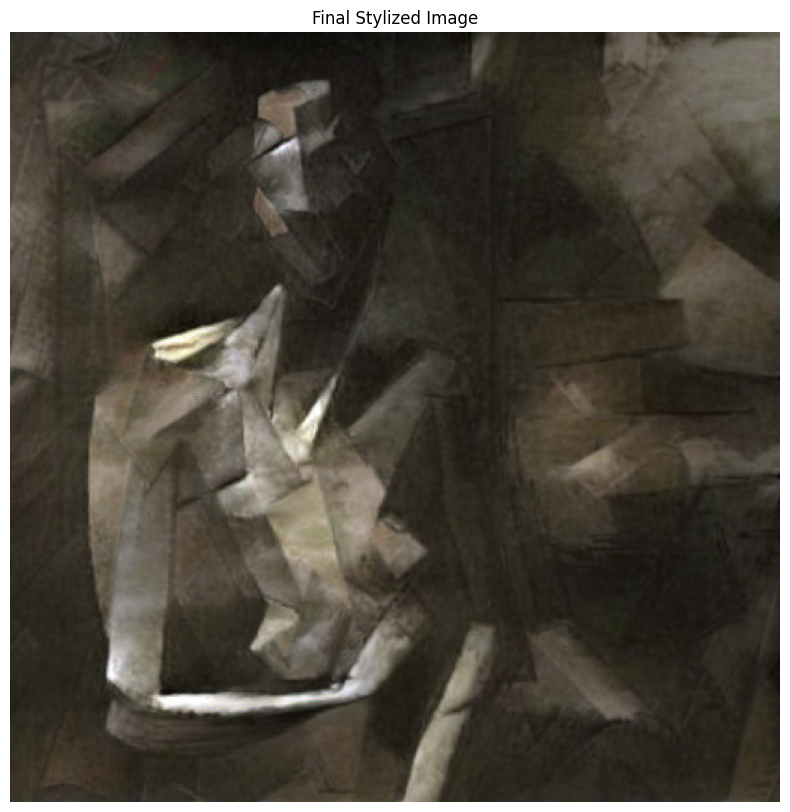

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

content_url="https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
style_url="https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"
urllib.request.urlretrieve(content_url,"content.jpg")
urllib.request.urlretrieve(style_url,"style.jpg")

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

imsize=512 if torch.cuda.is_available() else 256
loader=transforms.Compose([transforms.Resize((imsize,imsize)),transforms.ToTensor()])

def load_image(path):
    image=Image.open(path).convert("RGB")
    image=loader(image).unsqueeze(0)
    return image.to(device,torch.float)

content_img=load_image("content.jpg")
style_img=load_image("style.jpg")

unloader=transforms.ToPILImage()

def imshow(tensor,title=None):
    image=tensor.cpu().clone().squeeze(0)
    image=unloader(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

plt.figure()
imshow(content_img,"Content Image")
plt.figure()
imshow(style_img,"Style Image")

cnn=models.vgg19(pretrained=True).features.to(device).eval()
for param in cnn.parameters():
    param.requires_grad=False

cnn_normalization_mean=torch.tensor([0.485,0.456,0.406]).to(device)
cnn_normalization_std=torch.tensor([0.229,0.224,0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self,mean,std):
        super().__init__()
        self.mean=mean.view(-1,1,1)
        self.std=std.view(-1,1,1)
    def forward(self,img):
        return (img-self.mean)/self.std

class ContentLoss(nn.Module):
    def __init__(self,target):
        super().__init__()
        self.target=target.detach()
    def forward(self,input):
        self.loss=nn.functional.mse_loss(input,self.target)
        return input

def gram_matrix(input):
    b,c,h,w=input.size()
    features=input.view(c,h*w)
    G=torch.mm(features,features.t())
    return G.div(c*h*w)

class StyleLoss(nn.Module):
    def __init__(self,target_feature):
        super().__init__()
        self.target=gram_matrix(target_feature).detach()
    def forward(self,input):
        G=gram_matrix(input)
        self.loss=nn.functional.mse_loss(G,self.target)
        return input

content_layers=['conv_4']
style_layers=['conv_1','conv_2','conv_3','conv_4','conv_5']

def get_style_model_and_losses(cnn,normalization_mean,normalization_std,style_img,content_img):
    normalization=Normalization(normalization_mean,normalization_std).to(device)
    content_losses=[]
    style_losses=[]
    model=nn.Sequential(normalization)
    i=0
    for layer in cnn.children():
        if isinstance(layer,nn.Conv2d):
            i+=1
            name=f'conv_{i}'
        elif isinstance(layer,nn.ReLU):
            name=f'relu_{i}'
            layer=nn.ReLU(inplace=False)
        elif isinstance(layer,nn.MaxPool2d):
            name=f'pool_{i}'
        else:
            name=f'layer_{i}'
        model.add_module(name,layer)
        if name in content_layers:
            target=model(content_img).detach()
            content_loss=ContentLoss(target)
            model.add_module(f"content_loss_{i}",content_loss)
            content_losses.append(content_loss)
        if name in style_layers:
            target_feature=model(style_img).detach()
            style_loss=StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}",style_loss)
            style_losses.append(style_loss)
    return model,style_losses,content_losses

input_img=content_img.clone()
optimizer=optim.LBFGS([input_img.requires_grad_()])

def run_style_transfer(cnn,normalization_mean,normalization_std,content_img,style_img,input_img,num_steps=300,style_weight=1000000,content_weight=1):
    model,style_losses,content_losses=get_style_model_and_losses(cnn,normalization_mean,normalization_std,style_img,content_img)
    run=[0]
    while run[0]<=num_steps:
        def closure():
            input_img.data.clamp_(0,1)
            optimizer.zero_grad()
            model(input_img)
            style_score=0
            content_score=0
            for sl in style_losses:
                style_score+=sl.loss
            for cl in content_losses:
                content_score+=cl.loss
            loss=style_weight*style_score+content_weight*content_score
            loss.backward()
            run[0]+=1
            if run[0]%50==0:
                print("Step",run[0],"Style Loss:",style_score.item(),"Content Loss:",content_score.item())
            return loss
        optimizer.step(closure)
    input_img.data.clamp_(0,1)
    return input_img

output=run_style_transfer(cnn,cnn_normalization_mean,cnn_normalization_std,content_img,style_img,input_img)

plt.figure(figsize=(10,10))
imshow(output,"Final Stylized Image")
plt.show()